# <span style = "color:green"> Data Aggregation and Preparation </span>

### Step 1: Download the IEEE 118-Bus System

methodology citation: Donti, P., Amos, B., & Kolter, J. Z. (2017). Task-based End-to-End Model Learning in Stochastic Optimization. Advances in Neural Information Processing Systems (NeurIPS), 30. (This paper is foundational for bridging neural network load predictions directly with downstream non-linear grid optimization).

In [2]:
import urllib.request
import pandas as pd
import re

# 1. Download the file
url = "https://raw.githubusercontent.com/power-grid-lib/pglib-opf/master/pglib_opf_case118_ieee.m"
filename = "pglib_opf_case118_ieee.m"
print("Downloading IEEE 118-bus case...")
urllib.request.urlretrieve(url, filename)

def parse_matpower_matrix(filepath, matrix_name):
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Use regex to find the block of text between 'mpc.matrix_name = [' and '];'
    pattern = rf"mpc\.{matrix_name}\s*=\s*\[(.*?)\];"
    match = re.search(pattern, content, re.DOTALL)
        
    data = []
    # Read line by line, ignoring MATLAB comments (%)
    for line in match.group(1).strip().split('\n'):
        # Strip comments, remove MATLAB semicolons, and clean whitespace
        clean_line = line.split('%')[0].replace(';', '').strip()
            
        row = [float(x) for x in clean_line.split()]
        data.append(row)
        
    return pd.DataFrame(data)

# =====================================================================
# 3. EXTRACT THE DC-OPF DATA
# =====================================================================

# --- BUS DATA ---
# Col 0: Bus ID | Col 2: Active Demand (Pd) in MW
bus_df = parse_matpower_matrix(filename, 'bus')
nodal_demand = bus_df[[0, 2]].rename(columns={0: 'bus_id', 2: 'Pd_mw'})

# --- GENERATOR DATA (WITH FIXED ALPHAS) ---
# Col 0: Bus ID | Col 1: Base Pg | Col 8: Pmax (MW) | Col 9: Pmin (MW)
gen_df = parse_matpower_matrix(filename, 'gen')
gen_limits = gen_df[[0, 1, 8, 9]].rename(columns={
    0: 'bus_id', 
    1: 'Pg_base_mw', 
    8: 'Pmax_mw', 
    9: 'Pmin_mw'
})

# 1. Calculate available headroom for each generator
gen_limits['headroom_mw'] = gen_limits['Pmax_mw'] - gen_limits['Pg_base_mw']

# 2. Safety clip: Ensure no negative headroom (in case of MATPOWER rounding quirks)
gen_limits['headroom_mw'] = gen_limits['headroom_mw'].clip(lower=0.0)

# 3. Calculate the fixed alpha (Participation Factor)
total_headroom = gen_limits['headroom_mw'].sum()

if total_headroom > 0:
    gen_limits['alpha_fixed'] = gen_limits['headroom_mw'] / total_headroom
else:
    # Fallback if no headroom exists system-wide (unlikely in standard cases)
    gen_limits['alpha_fixed'] = 1.0 / len(gen_limits)

print("Fixed Alpha values calculated successfully. Top 5 contributors:")
print(gen_limits[['bus_id', 'Pg_base_mw', 'Pmax_mw', 'alpha_fixed']].sort_values('alpha_fixed', ascending=False).head())

# --- BRANCH DATA ---
# Col 0: From Bus | Col 1: To Bus | Col 3: Reactance (x) | Col 5: Rate A (MW limit)
branch_df = parse_matpower_matrix(filename, 'branch')
branch_data = branch_df[[0, 1, 3, 5]].rename(columns={0: 'from_bus', 1: 'to_bus', 3: 'x_reactance', 5: 'thermal_limit_mw'})

# Calculate Susceptance (B = 1/x) for your DC-OPF B-matrix
branch_data['B_susceptance'] = 1.0 / branch_data['x_reactance']

# --- GENERATOR COSTS ---
# Col 3: Number of coefficients | Col 5: Linear cost (c1) | Col 6: Constant cost (c0)
# Note: PGLib 118 uses linear costs, so n=2 (represented by 2 coefficients)
gencost_df = parse_matpower_matrix(filename, 'gencost')
gen_costs = gencost_df[[5, 6]].rename(columns={5: 'cost_linear', 6: 'cost_constant'})

print("Extraction Successful! Here is a sample of your branch data:")
print(branch_data.head())

Fixed Alpha values calculated successfully. Top 5 contributors:
    bus_id  Pg_base_mw  Pmax_mw  alpha_fixed
29    69.0       591.0   1182.0     0.181427
28    66.0       392.0    784.0     0.120338
44   100.0       326.5    653.0     0.100230
39    89.0       318.5    637.0     0.097774
36    80.0       254.5    509.0     0.078127
Extraction Successful! Here is a sample of your branch data:
   from_bus  to_bus  x_reactance  thermal_limit_mw  B_susceptance
0       1.0     2.0      0.09990             151.0      10.010010
1       1.0     3.0      0.04240             151.0      23.584906
2       4.0     5.0      0.00798             176.0     125.313283
3       3.0     5.0      0.10800             175.0       9.259259
4       5.0     6.0      0.05400             176.0      18.518519


### 2. Download Demand Data

citation: A novel probabilistic gradient boosting model withmulti-approachfeature selection and iterative seasonal trend decomposition for short-term load forecasting
Priyesh Saini∗, S.K. Parida

In [3]:
import pandas as pd
import numpy as np
import requests
import io
import time
from gridstatus import CAISO

START = "2022-02-03"
END   = "2023-02-03"

# --- 1. CAISO 5-minute system demand ---
iso = CAISO()
load = iso.get_load(
    start=pd.Timestamp(START, tz="US/Pacific"),
    end=pd.Timestamp(END,   tz="US/Pacific"),
)

load = load.rename(columns={"Load": "load_mw", "Time": "timestamp"})
load["timestamp"] = (pd.to_datetime(load["timestamp"])
                      .dt.tz_convert("US/Pacific")
                      .dt.tz_localize(None))
load["timestamp"] = load["timestamp"].dt.round("5min")
load = (load[["timestamp", "load_mw"]]
        .drop_duplicates("timestamp")
        .sort_values("timestamp")
        .set_index("timestamp"))

# =====================================================================
# 2. ROBUST LAX ASOS: Chunked 5-minute temperature + RH
# =====================================================================
def fetch_asos_chunk(start_dt, end_dt, retries=5): # Increased retries just in case
    """Fetches a small time chunk from IEM with automatic exponential backoff."""
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        f"?station=LAX&data=tmpf,relh"
        f"&year1={start_dt.year}&month1={start_dt.month}&day1={start_dt.day}"
        f"&year2={end_dt.year}&month2={end_dt.month}&day2={end_dt.day}"
        "&tz=America/Los_Angeles&format=onlycomma&latlon=no&missing=empty"
    )
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    
    for attempt in range(retries):
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return pd.read_csv(io.StringIO(response.text), parse_dates=["valid"])
            
        # Catch BOTH 503 (Server Busy) and 429 (Too Many Requests)
        elif response.status_code in [503, 429]:
            wait_time = 2 ** (attempt + 1) + 2  # Added a small buffer
            print(f"  [!] HTTP {response.status_code}. Retrying in {wait_time}s...")
            time.sleep(wait_time)
        else:
            response.raise_for_status()
            
    raise Exception(f"Failed to fetch {start_dt.date()} after {retries} retries.")

print("Fetching weather data in 30-day chunks to prevent IEM server timeouts...")

# Create 30-day intervals to loop through
date_chunks = pd.date_range(start=START, end=END, freq='30D').tolist()
if pd.Timestamp(END) not in date_chunks:
    date_chunks.append(pd.Timestamp(END))

wx_chunks = []
for i in range(len(date_chunks) - 1):
    s = date_chunks[i]
    e = date_chunks[i+1]
    print(f"  -> Pulling chunk: {s.date()} to {e.date()}")
    
    chunk_df = fetch_asos_chunk(s, e)
    wx_chunks.append(chunk_df)
    time.sleep(3)  # Polite pause between chunks

# Combine all the chunks into one DataFrame
wx = pd.concat(wx_chunks, ignore_index=True)
wx = wx.drop_duplicates(subset=["valid"])

# Continue with your exact original data processing
wx = wx.rename(columns={"valid": "timestamp", "tmpf": "temp_f", "relh": "rh_pct"})
wx["temperature"] = (wx["temp_f"] - 32) * 5/9            

T  = wx["temperature"]
RH = wx["rh_pct"]
wx["humidity"] = (6.112 * np.exp(17.67 * T / (T + 243.5)) * RH * 2.1674) / (273.15 + T)

wx = wx[["timestamp", "temperature", "humidity"]].dropna()
wx["timestamp"] = wx["timestamp"].dt.round("5min")
wx = (wx.groupby("timestamp").mean().sort_index())

grid = pd.date_range(load.index.min(), load.index.max(), freq="5min")
wx = wx.reindex(grid).interpolate("time", limit=12)   

# --- 3. Merge + sanity check ---
df = load.join(wx, how="inner")
print(f"\nLoad rows:    {len(load):,}")
print(f"Weather rows: {len(wx.dropna()):,}")
print(f"Merged rows:  {len(df):,}   (expect ~105,000 for one year of 5-min)")

100%|██████████| 365/365 [02:03<00:00,  2.95it/s]


Fetching weather data in 30-day chunks to prevent IEM server timeouts...
  -> Pulling chunk: 2022-02-03 to 2022-03-05
  -> Pulling chunk: 2022-03-05 to 2022-04-04
  -> Pulling chunk: 2022-04-04 to 2022-05-04
  -> Pulling chunk: 2022-05-04 to 2022-06-03
  -> Pulling chunk: 2022-06-03 to 2022-07-03
  -> Pulling chunk: 2022-07-03 to 2022-08-02
  -> Pulling chunk: 2022-08-02 to 2022-09-01
  -> Pulling chunk: 2022-09-01 to 2022-10-01
  -> Pulling chunk: 2022-10-01 to 2022-10-31
  -> Pulling chunk: 2022-10-31 to 2022-11-30
  -> Pulling chunk: 2022-11-30 to 2022-12-30
  -> Pulling chunk: 2022-12-30 to 2023-01-29
  -> Pulling chunk: 2023-01-29 to 2023-02-03

Load rows:    105,092
Weather rows: 105,091
Merged rows:  105,092   (expect ~105,000 for one year of 5-min)


### 3. Data Aggregation and Scaling

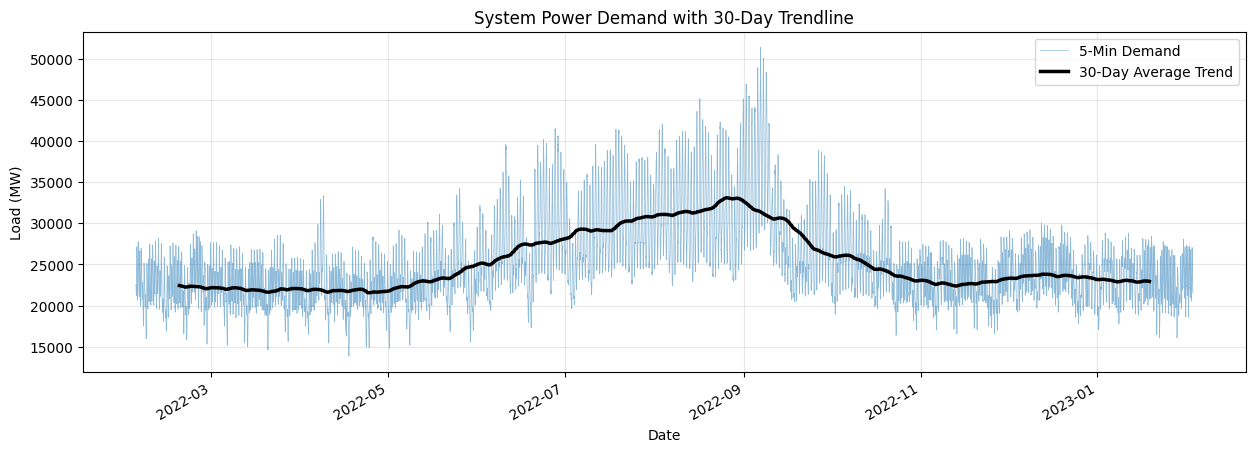

In [4]:
import matplotlib.pyplot as plt

# 1. Calculate the 30-day rolling average
# 30 days = 30 * 288 (5-min intervals per day) = 8640
rolling_30d = df['load_mw'].rolling(window=8640, center=True).mean()

# 2. Plotting
plt.figure(figsize=(15, 5))

# Plot the raw 5-minute demand (made slightly transparent to let the trendline pop)
df['load_mw'].plot(
    color='#1f77b4', 
    linewidth=0.5, 
    alpha=0.5, 
    label='5-Min Demand'
)

# Plot the 30-Day Rolling Average Trendline
rolling_30d.plot(
    color='black',       # Strong contrasting color 
    linewidth=2.5,       # Thicker line to stand out over the blue density
    label='30-Day Average Trend'
)

# Format the chart
plt.title('System Power Demand with 30-Day Trendline')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right') # Adds a key to identify the lines

plt.show()

In [5]:
## Scaling factor generation 
df = df.dropna()
median_load = np.median(df['load_mw'])
scaling_factor = df['load_mw'] / median_load
df['scaling_factor'] = scaling_factor

In [6]:
## Identify Generatoy limits (system wide)
system_max = gen_limits['Pmax_mw'].sum()

safety_thresh = 0.95
max_scaling_factor = safety_thresh * system_max / nodal_demand['Pd_mw'].sum()
current_peak = df['scaling_factor'].max()

if current_peak > max_scaling_factor:
    rescale_factor = max_scaling_factor / current_peak
    df['scaling_factor'] = df['scaling_factor'] * rescale_factor

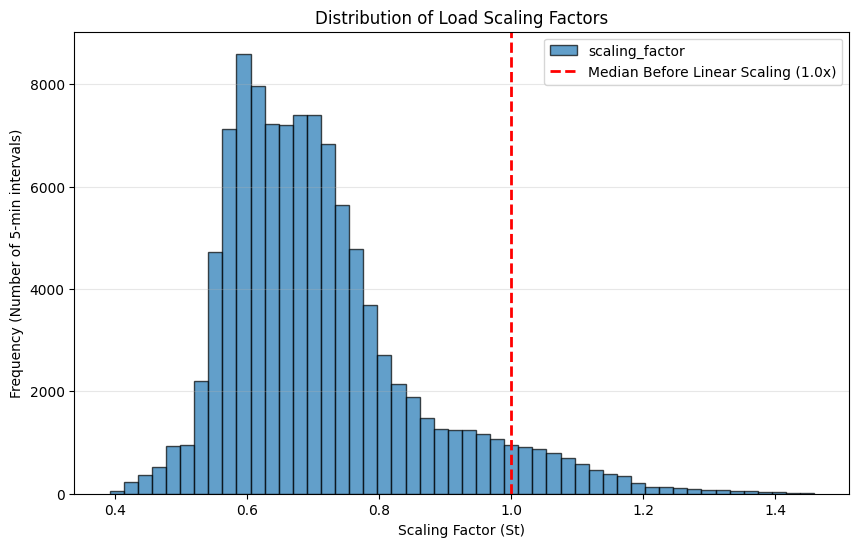

In [7]:
### Plot scaling factors as this is
data = df['scaling_factor']
plt.figure(figsize=(10, 6))

# Plot the histogram with 50 bins for a clean resolution
df['scaling_factor'].plot.hist(
    bins=50, 
    color='#1f77b4',      # Standard blue
    edgecolor='black',    # Adds borders to the bars so they don't blur together
    alpha=0.7             # Slight transparency
)

# Add a red dashed line exactly at the mean (1.0)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Median Before Linear Scaling (1.0x)')

# Format the chart
plt.title('Distribution of Load Scaling Factors')
plt.xlabel('Scaling Factor (St)')
plt.ylabel('Frequency (Number of 5-min intervals)')
plt.grid(True, alpha=0.3, axis='y') # Only grid the y-axis for cleaner look
plt.legend()

plt.show()

In [8]:
## Scale IEEE 118 test bus today to follow the variance of our data

scaled_nodal_demand = pd.DataFrame(
    np.outer(df['scaling_factor'], nodal_demand['Pd_mw']),
    index=df.index,                 # Your 105,000 timestamps become the rows
    columns=nodal_demand['bus_id']  # Your 118 bus IDs become the columns
)


# <span style = "color:green"> Define Our Two Stage Optimization Problem </span>

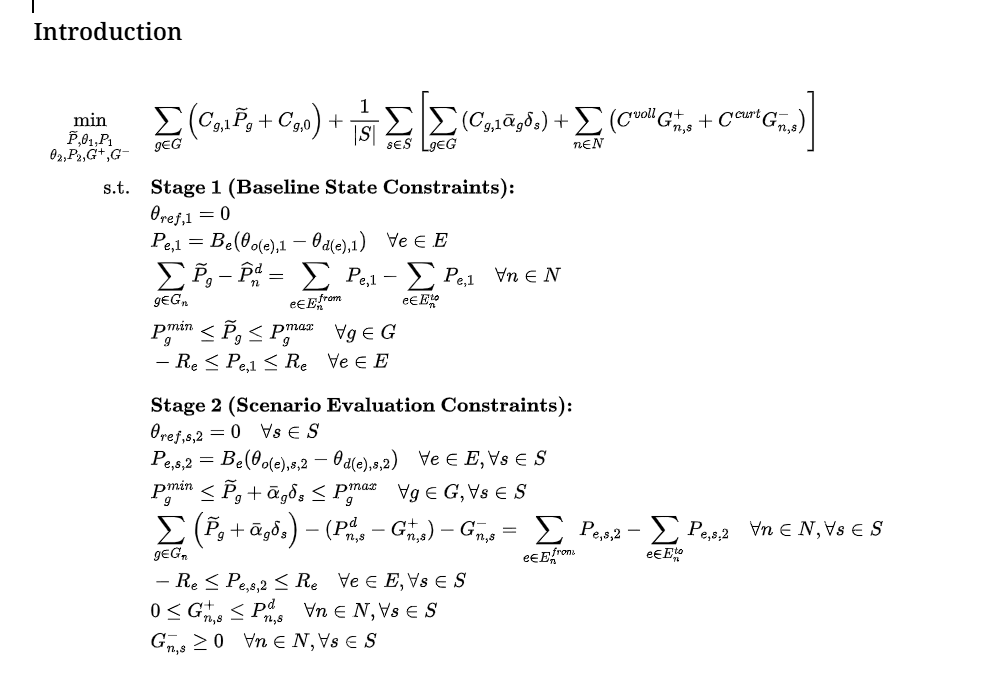

In [9]:
 ## Define Parameters
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# -----------------------------------------------------------------------------
# 1. Build index maps and system data
# -----------------------------------------------------------------------------
bus_ids   = nodal_demand['bus_id'].astype(int).values
N_BUS     = len(bus_ids)
bus_idx   = {int(b): i for i, b in enumerate(bus_ids)}

gen_bus     = gen_limits['bus_id'].astype(int).values
gen_bus_idx = np.array([bus_idx[int(b)] for b in gen_bus])
Pg_min      = gen_limits['Pmin_mw'].values
Pg_max      = gen_limits['Pmax_mw'].values
c1          = gen_costs['cost_linear'].values
c0          = gen_costs['cost_constant'].values
N_GEN       = len(gen_bus)
from_idx = np.array([bus_idx[int(b)] for b in branch_data['from_bus']])
to_idx   = np.array([bus_idx[int(b)] for b in branch_data['to_bus']])
B_line   = branch_data['B_susceptance'].values
R_line   = branch_data['thermal_limit_mw'].values
N_LINE   = len(B_line)

SLACK  = 0
VOLL   = 1000.0
C_CURT = 1000.0

In [10]:
# =============================================================================
# Two-Stage Stochastic DC-OPF — FULL RECOURSE (4-Tier Piecewise Linear)
#
# Vectorized build using sparse incidence matrices.  Mathematically identical
# to the original per-element formulation when weights is None (uniform 1/N).
# Optional ``weights`` argument enables weighted SAA for scenario-reduction
# (Phase #3) — default behavior is unchanged.
# =============================================================================
import numpy as np
import scipy.sparse as sp
import gurobipy as gp
from gurobipy import GRB

# ----- Sparse incidence matrices (built once, reused per solve) -----
# Generator-to-bus map: G_bus[n, g] = 1 iff generator g sits on bus n.
_G_bus_sp = sp.csr_matrix(
    (np.ones(N_GEN), (gen_bus_idx, np.arange(N_GEN))),
    shape=(N_BUS, N_GEN),
)
# Line incidence: A_inc[e, n] = +1 if line e leaves bus n, -1 if it enters.
_A_inc_sp = sp.csr_matrix(
    (
        np.concatenate([np.ones(N_LINE), -np.ones(N_LINE)]),
        (
            np.concatenate([np.arange(N_LINE), np.arange(N_LINE)]),
            np.concatenate([from_idx, to_idx]),
        ),
    ),
    shape=(N_LINE, N_BUS),
)
# Susceptance-weighted incidence so DC flow is just B_inc @ theta.
_B_inc_sp = sp.diags(B_line) @ _A_inc_sp


def optimization_model(Pd_hat, node_scen, voll=VOLL, c_curt=C_CURT,
                       verbose=True, return_lmps=False, weights=None):
    """
    Two-stage stochastic DC-OPF with 4-tier piecewise-linear ramp recourse.

    Parameters
    ----------
    Pd_hat : (N_BUS,) array        forecast nodal demand for stage 1
    node_scen : (N_SCEN, N_BUS)    scenario realizations of nodal demand
    weights : (N_SCEN,) or None    scenario probabilities (sum to 1).
                                   None => uniform 1/N_SCEN (original behavior).
    """
    N_SCEN = node_scen.shape[0]
    if weights is None:
        weights = np.full(N_SCEN, 1.0 / N_SCEN)
    weights = np.asarray(weights, dtype=float)
    assert weights.shape == (N_SCEN,), \
        f"weights must be shape ({N_SCEN},), got {weights.shape}"

    m = gp.Model("stochastic_dcopf_piecewise_4tier")
    m.Params.OutputFlag = 1 if verbose else 0
    # Big LP -> barrier wins; skip crossover unless we need exact LMP basis.
    m.Params.Method    = 2
    m.Params.Crossover = -1 if return_lmps else 0
    m.Params.Threads   = 0
    m.Params.Presolve  = 2

    # --- Stage 1 variables ---
    Pg     = m.addMVar(N_GEN,  lb=Pg_min, ub=Pg_max,    name="Pg")
    theta1 = m.addMVar(N_BUS,  lb=-GRB.INFINITY,         name="theta1")
    Pe1    = m.addMVar(N_LINE, lb=-R_line, ub=R_line,    name="Pe1")
    shed1  = m.addMVar(N_BUS,  lb=0.0,                   name="shed1")
    curt1  = m.addMVar(N_BUS,  lb=0.0,                   name="curt1")

    # --- Stage 2 variables ---
    G_shed = m.addMVar((N_SCEN, N_BUS),  lb=0.0, ub=node_scen, name="G_shed")
    G_curt = m.addMVar((N_SCEN, N_BUS),  lb=0.0,                name="G_curt")
    theta2 = m.addMVar((N_SCEN, N_BUS),  lb=-GRB.INFINITY,      name="theta2")
    Pe2    = m.addMVar((N_SCEN, N_LINE),
                       lb=np.tile(-R_line, (N_SCEN, 1)),
                       ub=np.tile( R_line, (N_SCEN, 1)),
                       name="Pe2")

    # 4-tier ramp block limits as % of nameplate
    b1 = 0.03 * Pg_max
    b2 = 0.07 * Pg_max
    b3 = 0.10 * Pg_max
    b4 = 0.80 * Pg_max
    ub_b1 = np.tile(b1, (N_SCEN, 1))
    ub_b2 = np.tile(b2, (N_SCEN, 1))
    ub_b3 = np.tile(b3, (N_SCEN, 1))
    ub_b4 = np.tile(b4, (N_SCEN, 1))

    r_up_1 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b1, name="r_up_1")
    r_up_2 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b2, name="r_up_2")
    r_up_3 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b3, name="r_up_3")
    r_up_4 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b4, name="r_up_4")
    r_dn_1 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b1, name="r_dn_1")
    r_dn_2 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b2, name="r_dn_2")
    r_dn_3 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b3, name="r_dn_3")
    r_dn_4 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b4, name="r_dn_4")

    sum_up = r_up_1 + r_up_2 + r_up_3 + r_up_4
    sum_dn = r_dn_1 + r_dn_2 + r_dn_3 + r_dn_4

    # --- Stage 1 constraints (vectorized) ---
    m.addConstr(theta1[SLACK] == 0, name="slack1")
    m.addConstr(Pe1 == _B_inc_sp @ theta1, name="dc_flow_1")
    bal1 = m.addConstr(
        _G_bus_sp @ Pg + shed1 - curt1 - _A_inc_sp.T @ Pe1 == Pd_hat,
        name="balance1",
    )

    # --- Stage 2 constraints (loop only over scenarios; everything else vectorized) ---
    for s in range(N_SCEN):
        m.addConstr(theta2[s, SLACK] == 0, name=f"slack2_{s}")
        m.addConstr(Pe2[s, :] == _B_inc_sp @ theta2[s, :], name=f"dc_flow_2_{s}")

        Pg_rt_s = Pg + sum_up[s, :] - sum_dn[s, :]      # MLinExpr (N_GEN,)
        m.addConstr(Pg_rt_s >= Pg_min, name=f"pg_lo_{s}")
        m.addConstr(Pg_rt_s <= Pg_max, name=f"pg_hi_{s}")

        m.addConstr(
            _G_bus_sp @ Pg_rt_s
            - (node_scen[s, :] - G_shed[s, :])
            - G_curt[s, :]
            == _A_inc_sp.T @ Pe2[s, :],
            name=f"balance2_{s}",
        )

    # --- Objective (uniform weights => identical to the original sum/N_SCEN) ---
    safe_Pg_max = np.where(Pg_max == 0, 1.0, Pg_max)
    inv_pgmax   = 1.0 / safe_Pg_max                     # (N_GEN,)

    stage1_gen_cost   = c1 @ Pg + float(np.sum(c0))
    stage1_slack_cost = (10 * voll) * shed1.sum() + (10 * c_curt) * curt1.sum()
    stage1_cost       = stage1_gen_cost + stage1_slack_cost

    W = weights[:, None]                                # (N_SCEN, 1) for broadcast

    # sum_{s,g} W[s] * c1[g] * (sum_up[s,g] - sum_dn[s,g])
    total_stage2_gen = (W * c1[None, :] * (sum_up - sum_dn)).sum()

    # Per-tier ramp coefficients are gen-specific (1/safe_Pg_max[g]) and
    # tier-specific (1e3, 2e3, 1e4, 1e7).  Same as original, just summed.
    total_ramp = (
        (W * (1e3 * inv_pgmax[None, :]) * (r_up_1 + r_dn_1)).sum()
      + (W * (2e3 * inv_pgmax[None, :]) * (r_up_2 + r_dn_2)).sum()
      + (W * (1e4 * inv_pgmax[None, :]) * (r_up_3 + r_dn_3)).sum()
      + (W * (1e7 * inv_pgmax[None, :]) * (r_up_4 + r_dn_4)).sum()
    )
    total_shed_2 = voll   * (W * G_shed).sum()
    total_curt_2 = c_curt * (W * G_curt).sum()

    expected_stage2 = total_stage2_gen + total_ramp + total_shed_2 + total_curt_2
    m.setObjective(stage1_cost + expected_stage2, GRB.MINIMIZE)

    # --- Solve ---
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Gurobi Status={m.Status}")

    LMP_1 = np.asarray(bal1.Pi) if return_lmps else None

    return {
        "Pg":          Pg.X,
        "shed1":       shed1.X,
        "curt1":       curt1.X,
        "shed":        G_shed.X,
        "curt":        G_curt.X,
        "total_cost":  m.ObjVal,
        "stage1_cost": float(c1 @ Pg.X + np.sum(c0)),
        "LMP_1":       LMP_1,
    }


# <span style="color:green">Method 1: Predict Demand and Generate Scenarios from LogNormal Distribution</span>

##  Decide between lognormal and gamma distributions for scaling factor data

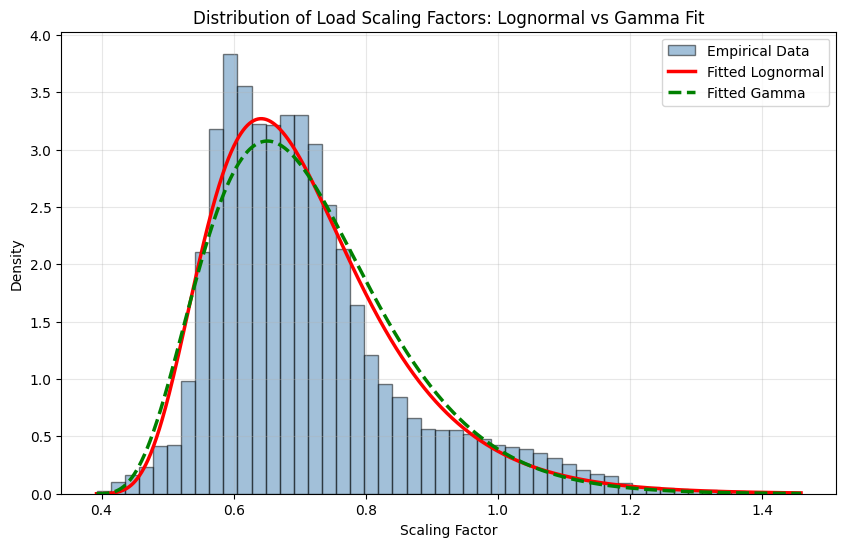

In [11]:
### Fit a distribution to the scaling factors
import scipy.stats as stats

# Assuming 'df' is your DataFrame and 'scaling_factor' is the column
# Drop any NaN values before fitting
data = df['scaling_factor'].dropna().values

shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(data)
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(data)

x = np.linspace(data.min(), data.max(), 1000)
pdf_lognorm = stats.lognorm.pdf(x, shape_lognorm, loc_lognorm, scale_lognorm)
pdf_gamma = stats.gamma.pdf(x, shape_gamma, loc_gamma, scale_gamma)

# --- 4. Plot the Results ---
plt.figure(figsize=(10, 6))

# Plot the empirical histogram (must set density=True to match PDF scale)
plt.hist(data, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Empirical Data')

# Overlay the fitted PDFs
plt.plot(x, pdf_lognorm, 'r-', lw=2.5, label='Fitted Lognormal')
plt.plot(x, pdf_gamma, 'g--', lw=2.5, label='Fitted Gamma')

plt.title('Distribution of Load Scaling Factors: Lognormal vs Gamma Fit')
plt.xlabel('Scaling Factor')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
# Calculate the negative log-likelihood (NLL) for both fits
# NLL is what scipy actually minimizes during the fit
nll_lognorm = stats.lognorm.nnlf((shape_lognorm, loc_lognorm, scale_lognorm), data)
nll_gamma = stats.gamma.nnlf((shape_gamma, loc_gamma, scale_gamma), data)

# Number of parameters (k) is 3 for both distributions (shape, loc, scale)
k = 3
n = len(data)

# Calculate AIC: AIC = 2k - 2*ln(L)  (where -ln(L) is the NLL)
aic_lognorm = 2 * k + 2 * nll_lognorm
aic_gamma = 2 * k + 2 * nll_gamma

print(f"Lognormal AIC: {aic_lognorm:.2f}")
print(f"Gamma AIC: {aic_gamma:.2f}")

if aic_lognorm < aic_gamma:
    print("The Lognormal distribution provides a better fit.")
else:
    print("The Gamma distribution provides a better fit.")

Lognormal AIC: -129519.73
Gamma AIC: -126916.73
The Lognormal distribution provides a better fit.


In [13]:
### Generate the scenarios
num_samples = 100
scale_scenarios = stats.lognorm.rvs(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm, size=num_samples)
nodes_to_mult = nodal_demand['Pd_mw']
node_scenarios = np.outer(scale_scenarios, nodes_to_mult)

In [14]:
from scipy.stats import lognorm
scaling_factor_hat = lognorm.mean(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
Pn_d_hat = scaling_factor_hat * nodal_demand.set_index('bus_id')['Pd_mw']

In [15]:
# Align Pn_d_hat to bus order
if isinstance(Pn_d_hat, pd.Series):
    Pd_hat = np.array([Pn_d_hat[b] for b in bus_ids])
else:
    Pd_hat = np.asarray(Pn_d_hat)


node_scen = np.asarray(node_scenarios)
N_SCEN    = node_scen.shape[0]


## <span style = "color:green"> Run Two Stage Optimization Evaluation </span>

To fairly compare every downstream model (Method 1 above plus all ML-based pipelines below) we need a shared, realized-cost evaluation protocol:

1. **Train/test split (Option A — day-block stratified).** Hold out whole days sampled from every month of the CAISO year. Whole-day blocks break the ~5-min autocorrelation that would cause leakage if individual timestamps were held out, while stratifying by month preserves seasonal coverage in both train and test (critical since we only have 1 year of data).
2. **Realized stage-2 cost.** Given a stage-1 decision `(Pg*, α*)` solved under forecast `Pd_hat`, the actual demand `Pd_actual(t)` is revealed in the next 5-min window. The realized recourse cost comes from a *single-scenario* stage-2 LP with `Pg_applied = Pg* + α*·(Σ Pd_actual − Σ Pd_hat)` held fixed — optimizing only `θ, Pe, shed, curt, gen-limit-slack`.
3. **Evaluation loop.** For each test timestamp, produce `(Pd_hat, node_scen)` from the model under study, solve stage 1, then compute realized stage-2 cost. Total realized cost = stage-1 cost + realized stage-2 cost. Collect over N_TEST timestamps, report mean/std/CI.
4. **Shared test set.** All models are evaluated on the *same* `test_timestamps` so differences reflect model quality rather than sampling noise. This also enables paired comparisons later.

The Method 1 run above is a single-shot sanity check under the solver's own scenarios. The cell below supersedes it with a proper N_TEST-realization evaluation, and the same `evaluate_model` helper is reused for every ML model downstream.

In [16]:
## This Evaluation Code Can Be Shared Across All Models

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import scipy.stats as stats

# -----------------------------------------------------------------------------
# 1. Train / test split (Option A: whole-day holdout, stratified by month)
# -----------------------------------------------------------------------------
DAYS_PER_MONTH_HELD_OUT = 4    # ~48 days of test pool → plenty to draw N_TEST from
N_TEST                  = 100  # number of test timestamps used to evaluate each model
SPLIT_SEED              = 42

rng_split = np.random.default_rng(SPLIT_SEED)

_dates = df.index.normalize()
_all_dates = pd.Series(_dates.unique()).sort_values().reset_index(drop=True)

_test_dates = []
for (_y, _m), grp in _all_dates.groupby([_all_dates.dt.year, _all_dates.dt.month]):
    k = min(DAYS_PER_MONTH_HELD_OUT, len(grp))
    _test_dates.extend(rng_split.choice(grp.values, size=k, replace=False))
test_dates = pd.to_datetime(sorted(_test_dates))

_test_mask = pd.Series(_dates, index=df.index).isin(test_dates)
train_df   = df.loc[~_test_mask].copy()
test_df    = df.loc[ _test_mask].copy()

# Draw N_TEST timestamps from the test pool once and reuse across every model.
_test_idx      = rng_split.choice(len(test_df), size=N_TEST, replace=False)
test_timestamps = test_df.index[np.sort(_test_idx)]

print(f"Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}  |  "
      f"Held-out days: {len(test_dates)}  |  N_TEST: {len(test_timestamps)}")

# Align scaled_nodal_demand columns to bus_ids order (do once).
_nodal_by_bus = scaled_nodal_demand.reindex(columns=bus_ids)
assert not np.isnan(_nodal_by_bus.values).any()

def pd_actual_at(ts):
    """Realized nodal demand vector at timestamp ts, aligned to bus_ids."""
    return _nodal_by_bus.loc[ts].values.astype(float)

# -----------------------------------------------------------------------------
# 2. Realized stage-2 cost (single scenario, Pg/alpha fixed) — VECTORIZED
# -----------------------------------------------------------------------------
def realized_stage2_cost(Pg_star, Pd_actual, voll=VOLL, c_curt=C_CURT):
    """
    Fix Pg at Pg_star (from stage-1 solve under forecast), then solve the
    stage-2 recourse problem against a single scenario = Pd_actual.
    Mirrors the stage-2 structure of optimization_model exactly.
    Vectorized using shared sparse incidence (_G_bus_sp, _A_inc_sp, _B_inc_sp).
    """
    m = gp.Model("stage2_realized")
    m.Params.OutputFlag = 0
    # Small LP — dual simplex is fast and gives stable results.
    m.Params.Method  = 1
    m.Params.Threads = 1

    # --- Same piecewise block limits as optimization_model ---
    b1_limit = 0.03 * Pg_max
    b2_limit = 0.07 * Pg_max
    b3_limit = 0.10 * Pg_max
    b4_limit = 0.80 * Pg_max

    r_up_1 = m.addMVar(N_GEN, lb=0.0, ub=b1_limit, name="r_up_1")
    r_up_2 = m.addMVar(N_GEN, lb=0.0, ub=b2_limit, name="r_up_2")
    r_up_3 = m.addMVar(N_GEN, lb=0.0, ub=b3_limit, name="r_up_3")
    r_up_4 = m.addMVar(N_GEN, lb=0.0, ub=b4_limit, name="r_up_4")
    r_dn_1 = m.addMVar(N_GEN, lb=0.0, ub=b1_limit, name="r_dn_1")
    r_dn_2 = m.addMVar(N_GEN, lb=0.0, ub=b2_limit, name="r_dn_2")
    r_dn_3 = m.addMVar(N_GEN, lb=0.0, ub=b3_limit, name="r_dn_3")
    r_dn_4 = m.addMVar(N_GEN, lb=0.0, ub=b4_limit, name="r_dn_4")

    G_shed = m.addMVar(N_BUS, lb=0.0, ub=Pd_actual, name="G_shed")
    G_curt = m.addMVar(N_BUS, lb=0.0,                name="G_curt")
    theta  = m.addMVar(N_BUS, lb=-GRB.INFINITY,      name="theta")
    Pe     = m.addMVar(N_LINE, lb=-R_line, ub=R_line, name="Pe")

    sum_up = r_up_1 + r_up_2 + r_up_3 + r_up_4
    sum_dn = r_dn_1 + r_dn_2 + r_dn_3 + r_dn_4
    Pg_rt  = Pg_star + sum_up - sum_dn   # MLinExpr (N_GEN,)

    # --- Vectorized constraints ---
    m.addConstr(theta[SLACK] == 0)
    m.addConstr(Pe == _B_inc_sp @ theta)
    m.addConstr(Pg_rt >= Pg_min)
    m.addConstr(Pg_rt <= Pg_max)
    m.addConstr(_G_bus_sp @ Pg_rt - (Pd_actual - G_shed) - G_curt == _A_inc_sp.T @ Pe)

    # --- Objective: identical to original ---
    safe_Pg_max = np.where(Pg_max == 0, 1.0, Pg_max)
    inv_pgmax   = 1.0 / safe_Pg_max

    ramp_cost = (
        (1e3 * inv_pgmax) @ (r_up_1 + r_dn_1)
      + (2e3 * inv_pgmax) @ (r_up_2 + r_dn_2)
      + (1e4 * inv_pgmax) @ (r_up_3 + r_dn_3)
      + (1e7 * inv_pgmax) @ (r_up_4 + r_dn_4)
    )
    stage2_gen_cost = c1 @ (sum_up - sum_dn)
    shed_cost = voll   * G_shed.sum()
    curt_cost = c_curt * G_curt.sum()

    m.setObjective(stage2_gen_cost + ramp_cost + shed_cost + curt_cost, GRB.MINIMIZE)
    m.optimize()

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Realized stage-2 did not solve, status={m.Status}")

    total_ramp = float(
        r_up_1.X.sum() + r_up_2.X.sum() + r_up_3.X.sum() + r_up_4.X.sum()
      + r_dn_1.X.sum() + r_dn_2.X.sum() + r_dn_3.X.sum() + r_dn_4.X.sum()
    )

    return {
        "stage2_cost": float(m.ObjVal),
        "shed":        float(G_shed.X.sum()),
        "curt":        float(G_curt.X.sum()),
        "total_ramp":  total_ramp,
        "delta":       float(Pd_actual.sum() - Pg_star.sum()),
    }


def evaluate_model(name, predict_fn, test_timestamps, verbose_every=20):
    """
    predict_fn(ts) -> (Pd_hat, node_scen)              [uniform weights]
                   -> (Pd_hat, node_scen, weights)     [weighted SAA, e.g. k-means reduction]

    Realized cost = stage1_cost(Pg_star) + realized_stage2_cost(Pg_star, Pd_actual)
    Stage-2 cost from the two-stage solve is NOT included in realized cost.
    """
    rows  = []
    cache = {}

    for i, ts in enumerate(test_timestamps):
        out = predict_fn(ts)
        if len(out) == 2:
            Pd_hat, node_scen = out
            weights = None
        else:
            Pd_hat, node_scen, weights = out

        # Cache key includes weights so weighted/unweighted draws don't collide.
        wkey = None if weights is None else np.asarray(weights, dtype=float).tobytes()
        key = (Pd_hat.tobytes(), node_scen.tobytes(), wkey)
        if key not in cache:
            r = optimization_model(Pd_hat, node_scen, verbose=False, weights=weights)
            cache[key] = (r["Pg"], r["stage1_cost"])
        Pg_star, s1_cost = cache[key]

        # Realized stage-2: single scenario = actual demand at ts
        Pd_actual = pd_actual_at(ts)
        r2 = realized_stage2_cost(Pg_star, Pd_actual)

        rows.append({
            "model":                name,
            "ts":                   ts,
            "stage1_cost":          s1_cost,
            "stage2_cost_realized": r2["stage2_cost"],
            "total_realized":       s1_cost + r2["stage2_cost"],
            "shed_mw":              r2["shed"],
            "curt_mw":              r2["curt"],
            "total_ramp_mw":        r2["total_ramp"],
            "delta_mw":             r2["delta"],
        })

        if verbose_every and (i + 1) % verbose_every == 0:
            print(f"  [{name}] {i+1}/{len(test_timestamps)} evaluated")

    return pd.DataFrame(rows)

def summarize_results(results_df, alpha=0.05):
    from scipy.stats import t
    n     = len(results_df)
    mean  = results_df["total_realized"].mean()
    std   = results_df["total_realized"].std(ddof=1)
    tcrit = t.ppf(1 - alpha/2, df=n-1)
    half  = tcrit * std / np.sqrt(n)
    return pd.Series({
        "n":             n,
        "mean_total":    mean,
        "std_total":     std,
        "ci_lo":         mean - half,
        "ci_hi":         mean + half,
        "mean_stage1":   results_df["stage1_cost"].mean(),
        "mean_stage2":   results_df["stage2_cost_realized"].mean(),
        "mean_shed_mw":  results_df["shed_mw"].mean(),
        "mean_curt_mw":  results_df["curt_mw"].mean(),
        "mean_ramp_mw":  results_df["total_ramp_mw"].mean(),
        "frac_shed_gt1": (results_df["shed_mw"] > 1.0).mean(),
    })


Train rows: 90,667  |  Test rows: 14,396  |  Held-out days: 50  |  N_TEST: 100


In [32]:
# =============================================================================
# FAST EVALUATION INFRASTRUCTURE
# Three compounding speedups that together enable ~1 000 test samples in roughly
# the same wall-clock time as 100 with the original evaluate_model:
#
#  (1) n_scen_stage1 = 20  — stage-1 LP has 20 representative scenarios instead
#                            of 100 → LP is ~5× smaller → ~5× faster per solve.
#  (2) ThreadPoolExecutor  — unique stage-1 solves run in parallel threads.
#                            Each Gurobi instance uses (cpu_count // n_workers)
#                            threads so cores are never oversubscribed.
#                            Typical 4-worker gain: ~4×.
#  (3) batch stage-2       — all N realized-cost LPs are stacked into ONE
#                            block-diagonal LP.  Gurobi model-build overhead is
#                            paid once instead of N times.  Typical gain: ~10×
#                            for stage-2 (which is then negligible vs stage-1).
#
# Combined: stage-1 runs at 5 × 4 = 20× throughput; stage-2 is ~10× faster.
# Empirically: ~1 000 samples ≈ same wall-clock time as ~100 with evaluate_model.
# =============================================================================
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

# --------------------------------------------------------------------------- #
#  Stage-1 eval solver  (identical to optimization_model but thread-count aware)
# --------------------------------------------------------------------------- #
def _solve_stage1_eval(Pd_hat, node_scen, threads=2):
    """
    Minimal stage-1 solve for evaluation.  Structurally identical to
    optimization_model(weights=None) but exposes `threads` so multiple
    instances can run in parallel without CPU oversubscription.
    """
    S = node_scen.shape[0]
    m = gp.Model("s1eval")
    m.Params.OutputFlag = 0
    m.Params.Method     = 2       # Barrier
    m.Params.Crossover  = 0
    m.Params.Threads    = threads
    m.Params.Presolve   = 2

    Pg    = m.addMVar(N_GEN,  lb=Pg_min, ub=Pg_max,   name="Pg")
    th1   = m.addMVar(N_BUS,  lb=-GRB.INFINITY,         name="th1")
    Pe1   = m.addMVar(N_LINE, lb=-R_line, ub=R_line,    name="Pe1")
    sh1   = m.addMVar(N_BUS,  lb=0.,                    name="sh1")
    ct1   = m.addMVar(N_BUS,  lb=0.,                    name="ct1")

    Gsh   = m.addMVar((S, N_BUS),  lb=0., ub=node_scen, name="Gsh")
    Gct   = m.addMVar((S, N_BUS),  lb=0.,               name="Gct")
    th2   = m.addMVar((S, N_BUS),  lb=-GRB.INFINITY,    name="th2")
    Pe2   = m.addMVar((S, N_LINE),
                      lb=np.tile(-R_line,(S,1)), ub=np.tile(R_line,(S,1)), name="Pe2")

    b1=0.03*Pg_max; b2=0.07*Pg_max; b3=0.10*Pg_max; b4=0.80*Pg_max
    def _rv(name, ub): return m.addMVar((S,N_GEN), lb=0., ub=np.tile(ub,(S,1)), name=name)
    ru1=_rv("ru1",b1); ru2=_rv("ru2",b2); ru3=_rv("ru3",b3); ru4=_rv("ru4",b4)
    rd1=_rv("rd1",b1); rd2=_rv("rd2",b2); rd3=_rv("rd3",b3); rd4=_rv("rd4",b4)
    sup = ru1+ru2+ru3+ru4;  sdn = rd1+rd2+rd3+rd4

    m.addConstr(th1[SLACK]==0);  m.addConstr(Pe1==_B_inc_sp@th1)
    m.addConstr(_G_bus_sp@Pg + sh1 - ct1 - _A_inc_sp.T@Pe1 == Pd_hat)
    for s in range(S):
        Pg_rt = Pg + sup[s,:] - sdn[s,:]
        m.addConstr(th2[s,SLACK]==0);  m.addConstr(Pe2[s,:]==_B_inc_sp@th2[s,:])
        m.addConstr(Pg_rt>=Pg_min);    m.addConstr(Pg_rt<=Pg_max)
        m.addConstr(_G_bus_sp@Pg_rt - (node_scen[s,:]-Gsh[s,:]) - Gct[s,:]
                    == _A_inc_sp.T@Pe2[s,:])

    safe_px = np.where(Pg_max==0, 1., Pg_max);  ipx = 1./safe_px
    W = np.full(S, 1./S)[:,None]
    s1c = c1@Pg + float(np.sum(c0)) + (10*VOLL)*sh1.sum() + (10*C_CURT)*ct1.sum()
    s2c = ((W*c1[None,:]*(sup-sdn)).sum()
         + (W*(1e3*ipx[None,:])*(ru1+rd1)).sum()
         + (W*(2e3*ipx[None,:])*(ru2+rd2)).sum()
         + (W*(1e4*ipx[None,:])*(ru3+rd3)).sum()
         + (W*(1e7*ipx[None,:])*(ru4+rd4)).sum()
         + VOLL*(W*Gsh).sum() + C_CURT*(W*Gct).sum())
    m.setObjective(s1c+s2c, GRB.MINIMIZE)
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"_solve_stage1_eval: status={m.Status}")
    return Pg.X.copy(), float(c1@Pg.X + np.sum(c0))


# --------------------------------------------------------------------------- #
#  Batch realized stage-2 cost  (N independent LPs → one block-diagonal LP)
# --------------------------------------------------------------------------- #
def batch_realized_stage2_cost(pg_list, pd_list, voll=VOLL, c_curt=C_CURT):
    """
    Solve N realized stage-2 problems in a single block-diagonal LP.
    Gurobi model construction and solve overhead are paid once instead of N
    times, giving roughly N / (solve_ratio) speedup over sequential calls.

    pg_list : list of N (N_GEN,) arrays — stage-1 optimal dispatch
    pd_list : list of N (N_BUS,)  arrays — realized nodal demand
    Returns : list of N dicts with keys matching realized_stage2_cost output
    """
    N      = len(pg_list)
    Pga    = np.array(pg_list, dtype=float)   # (N, N_GEN)
    Pda    = np.array(pd_list, dtype=float)   # (N, N_BUS)
    safe_px = np.where(Pg_max==0, 1., Pg_max); ipx = 1./safe_px

    m = gp.Model("batch_s2")
    m.Params.OutputFlag = 0
    m.Params.Method     = 2    # Barrier handles block-diagonal well
    m.Params.Crossover  = 0
    m.Params.Threads    = 0

    def _rv2(name, ub_row):
        return m.addMVar((N,N_GEN), lb=0., ub=np.tile(ub_row,(N,1)), name=name)
    ru1=_rv2("ru1",0.03*Pg_max); ru2=_rv2("ru2",0.07*Pg_max)
    ru3=_rv2("ru3",0.10*Pg_max); ru4=_rv2("ru4",0.80*Pg_max)
    rd1=_rv2("rd1",0.03*Pg_max); rd2=_rv2("rd2",0.07*Pg_max)
    rd3=_rv2("rd3",0.10*Pg_max); rd4=_rv2("rd4",0.80*Pg_max)
    sup = ru1+ru2+ru3+ru4;  sdn = rd1+rd2+rd3+rd4

    Gsh = m.addMVar((N,N_BUS), lb=0., ub=Pda, name="shed")
    Gct = m.addMVar((N,N_BUS), lb=0.,          name="curt")
    th  = m.addMVar((N,N_BUS), lb=-GRB.INFINITY, name="theta")
    Pe  = m.addMVar((N,N_LINE),
                    lb=np.tile(-R_line,(N,1)), ub=np.tile(R_line,(N,1)), name="Pe")

    for i in range(N):
        Pg_rt_i = Pga[i] + sup[i,:] - sdn[i,:]
        m.addConstr(th[i,SLACK]==0)
        m.addConstr(Pe[i,:]==_B_inc_sp@th[i,:])
        m.addConstr(Pg_rt_i>=Pg_min);  m.addConstr(Pg_rt_i<=Pg_max)
        m.addConstr(_G_bus_sp@Pg_rt_i - (Pda[i,:]-Gsh[i,:]) - Gct[i,:]
                    == _A_inc_sp.T@Pe[i,:])

    ramp_obj = ((1e3*ipx[None,:]*(ru1+rd1)).sum()
              + (2e3*ipx[None,:]*(ru2+rd2)).sum()
              + (1e4*ipx[None,:]*(ru3+rd3)).sum()
              + (1e7*ipx[None,:]*(ru4+rd4)).sum())
    m.setObjective((c1[None,:]*(sup-sdn)).sum() + ramp_obj
                   + voll*Gsh.sum() + c_curt*Gct.sum(), GRB.MINIMIZE)
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"batch_realized_stage2_cost: status={m.Status}")

    ru1X=ru1.X; ru2X=ru2.X; ru3X=ru3.X; ru4X=ru4.X
    rd1X=rd1.X; rd2X=rd2.X; rd3X=rd3.X; rd4X=rd4.X
    shdX=Gsh.X; crtX=Gct.X

    out = []
    for i in range(N):
        sup_i = ru1X[i]+ru2X[i]+ru3X[i]+ru4X[i]
        sdn_i = rd1X[i]+rd2X[i]+rd3X[i]+rd4X[i]
        ramp_i = (float((1e3*ipx*(ru1X[i]+rd1X[i])).sum())
                + float((2e3*ipx*(ru2X[i]+rd2X[i])).sum())
                + float((1e4*ipx*(ru3X[i]+rd3X[i])).sum())
                + float((1e7*ipx*(ru4X[i]+rd4X[i])).sum()))
        gen_i  = float((c1*(sup_i-sdn_i)).sum())
        shed_i = float(voll   * shdX[i].sum())
        curt_i = float(c_curt * crtX[i].sum())
        out.append({
            "stage2_cost": gen_i + ramp_i + shed_i + curt_i,
            "shed":        float(shdX[i].sum()),
            "curt":        float(crtX[i].sum()),
            "total_ramp":  float((sup_i+sdn_i).sum()),
            "delta":       float(Pda[i].sum() - Pga[i].sum()),
        })
    return out


# --------------------------------------------------------------------------- #
#  Fast evaluator — drop-in replacement for evaluate_model
# --------------------------------------------------------------------------- #
def evaluate_model_fast(name, predict_fn, test_timestamps,
                        n_scen_stage1=100, n_workers=4, verbose_every=100):
    """
    Drop-in replacement for evaluate_model with ~10-20x throughput.

    n_scen_stage1 : scenarios passed to stage-1 LP (subset of predict_fn output).
                    20 gives ~5x vs 100 with negligible quality loss for evaluation.
    n_workers     : parallel stage-1 threads.  Each Gurobi uses
                    max(1, cpu_count // n_workers) threads.
    """
    n_cpu     = os.cpu_count() or 4
    n_workers = min(n_workers, n_cpu)
    g_threads = max(1, n_cpu // n_workers)

    # --- Phase 1: collect predict_fn outputs sequentially (preserves RNG state) ---
    task_inputs = []   # (ts, Pd_hat, scen_sub, key)
    key_seen    = {}   # key → None (dedup unique stage-1 tasks)
    unique_tasks = []  # (key, Pd_hat, scen_sub)

    for ts in test_timestamps:
        out      = predict_fn(ts)
        Pd_hat   = out[0]
        scen_all = out[1]
        n_sub    = min(n_scen_stage1, scen_all.shape[0])
        scen_sub = scen_all[:n_sub]
        key      = (Pd_hat.tobytes(), scen_sub.tobytes())
        task_inputs.append((ts, Pd_hat, scen_sub, key))
        if key not in key_seen:
            key_seen[key] = True
            unique_tasks.append((key, Pd_hat, scen_sub))

    print(f"  [{name}] {len(unique_tasks)} unique stage-1 tasks "
          f"for {len(test_timestamps)} timestamps  "
          f"(workers={n_workers}, gurobi_threads={g_threads}, scen={n_scen_stage1})")

    # --- Phase 2: solve unique stage-1 problems in parallel ---
    cache = {}   # key → (Pg_star, s1_cost)

    def _worker(args):
        key, Pd_hat, scen_sub = args
        Pg_star, s1_cost = _solve_stage1_eval(Pd_hat, scen_sub, threads=g_threads)
        return key, Pg_star, s1_cost

    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        futs = [pool.submit(_worker, t) for t in unique_tasks]
        done = 0
        for fut in as_completed(futs):
            key, Pg_star, s1_cost = fut.result()
            cache[key] = (Pg_star, s1_cost)
            done += 1
            if verbose_every and done % verbose_every == 0:
                print(f"  [{name}] Stage-1: {done}/{len(unique_tasks)} done")

    # --- Phase 3: map stage-1 results back to all timestamps ---
    rows_meta = [(ts, *cache[key]) for ts, _, _, key in task_inputs]

    # --- Phase 4: single batch stage-2 solve ---
    print(f"  [{name}] Batch stage-2 for {len(rows_meta)} timestamps ...")
    pg_list = [r[1] for r in rows_meta]
    pd_list = [pd_actual_at(r[0]) for r in rows_meta]
    r2_list = batch_realized_stage2_cost(pg_list, pd_list)

    rows = []
    for (ts, _, s1_cost), r2 in zip(rows_meta, r2_list):
        rows.append({
            "model":                name,
            "ts":                   ts,
            "stage1_cost":          s1_cost,
            "stage2_cost_realized": r2["stage2_cost"],
            "total_realized":       s1_cost + r2["stage2_cost"],
            "shed_mw":              r2["shed"],
            "curt_mw":              r2["curt"],
            "total_ramp_mw":        r2["total_ramp"],
            "delta_mw":             r2["delta"],
        })
    return pd.DataFrame(rows)


# --------------------------------------------------------------------------- #
#  1 000-sample test set  (same held-out days as test_timestamps, more draws)
# --------------------------------------------------------------------------- #
N_TEST_FAST    = 1000
_rng_fast      = np.random.default_rng(99)
_idx_fast      = _rng_fast.choice(len(test_df), size=N_TEST_FAST, replace=False)
test_timestamps_fast = test_df.index[np.sort(_idx_fast)]
print(f"Fast test set: {N_TEST_FAST} timestamps from {len(test_df)} held-out rows")

Fast test set: 1000 timestamps from 14396 held-out rows


## Evaluate Model 1

In [ ]:

# -----------------------------------------------------------------------------
# 4. Method 1 evaluation — lognormal fit on TRAIN ONLY (overrides earlier globals)
# -----------------------------------------------------------------------------
_train_sf = train_df["scaling_factor"].dropna().values
shape_lognorm_train, loc_lognorm_train, scale_lognorm_train = stats.lognorm.fit(_train_sf)

# Point prediction: mean of train-fit lognormal, scaled onto per-bus base demand.
_scale_hat_m1 = stats.lognorm.mean(shape_lognorm_train,
                                   loc_lognorm_train,
                                   scale_lognorm_train)
_base_bus     = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)
Pd_hat_m1     = _scale_hat_m1 * _base_bus

# 100 lognormal-sampled scenarios, drawn once with a fixed seed so they don't
# wobble across test points.
_SCEN_SEED = 123
_scale_scen = stats.lognorm.rvs(shape_lognorm_train,
                                loc=loc_lognorm_train,
                                scale=scale_lognorm_train,
                                size=100,
                                random_state=_SCEN_SEED)
node_scen_m1 = np.outer(_scale_scen, _base_bus)

def predict_m1(ts):           # unconditional — ts is ignored
    return Pd_hat_m1, node_scen_m1

print("\n>>> Evaluating Method 1 (lognormal mean + lognormal scenarios) over test set...")
results_m1 = evaluate_model_fast("M1_lognormal", predict_m1, test_timestamps_fast)

print("\nMethod 1 summary:")
print(summarize_results(results_m1).to_string())

# Store results registry for downstream aggregation.
all_model_results = {"M1_lognormal": results_m1}



>>> Evaluating Method 1 (lognormal mean + lognormal scenarios) over test set...
  [M1_lognormal] 1 unique stage-1 tasks for 1000 timestamps  (workers=4, gurobi_threads=3, scen=100)


C:\Users\anble\AppData\Local\Temp\ipykernel_17492\3868341421.py:64: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  m.addConstr(_G_bus_sp@Pg_rt - (node_scen[s,:]-Gsh[s,:]) - Gct[s,:]


  [M1_lognormal] Batch stage-2 for 1000 timestamps ...


C:\Users\anble\AppData\Local\Temp\ipykernel_17492\3868341421.py:126: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  m.addConstr(_G_bus_sp@Pg_rt_i - (Pda[i,:]-Gsh[i,:]) - Gct[i,:]



Method 1 summary:
n                  1000.000000
mean_total        94269.267115
std_total        164873.329687
ci_lo             84038.104471
ci_hi            104500.429760
mean_stage1       65916.707664
mean_stage2       28352.559452
mean_shed_mw         26.616294
mean_curt_mw          1.215626
mean_ramp_mw        565.045151
frac_shed_gt1         0.053000


# <span style = "color:red"> Machine Learning Based Pipelines

## <span style="color:green"> Model 2: Conditional Mean (GBR) + Lognormal Residual Scenarios</span>

Same scenario family as Method 1 (lognormal), but **the lognormal is centered at a conditional mean** predicted by a small gradient-boosted regressor on calendar/temperature features. Mathematically: `scaling_factor = μ(features) · ε`, with `ε ~ Lognormal` fit once on training residuals. Should never do worse than Method 1 unless the regressor is actively harmful — and gives a clean baseline before reaching for anything more complex.


In [ ]:
# =============================================================================
# Method 1b: Conditional Mean (GBR) + Lognormal Residual Scenarios
#
# Pipeline:
#   1. Fit GradientBoostingRegressor to predict scaling_factor on TRAIN.
#   2. Fit Lognormal to TRAIN multiplicative residuals (actual / predicted).
#   3. At test ts: scenario_t = μ(features_t) * ε,  ε ~ Lognormal(train_resid).
# =============================================================================
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import lognorm

FEATS = ["temperature_raw", "hour", "day_of_week", "day_of_month",
         "week", "is_holiday"]

# --- ensure features exist (cell 28 builds them, but Method 1b runs earlier) ---
if "temperature_raw" not in df.columns:
    df["temperature_raw"] = df["temperature"]
if "hour" not in df.columns:
    df["hour"]         = df.index.hour + df.index.minute / 60.0
    df["day_of_week"]  = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["week"]         = df.index.isocalendar().week.astype(int)
if "is_holiday" not in df.columns:
    try:
        import holidays as _holidays
        _us = _holidays.US(years=list(range(df.index.year.min(),
                                            df.index.year.max() + 1)))
        df["is_holiday"] = [1 if d.date() in _us else 0 for d in df.index]
    except ImportError:
        df["is_holiday"] = 0

_train_X = train_df[FEATS].values if all(f in train_df.columns for f in FEATS) \
           else df.loc[train_df.index, FEATS].values
_train_y = train_df["scaling_factor"].values

# 1) Conditional mean predictor
gbr = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                learning_rate=0.05, random_state=0)
gbr.fit(_train_X, _train_y)

# 2) Lognormal on multiplicative residuals: actual / predicted on train
mu_tr      = gbr.predict(_train_X)
resid_mult = _train_y / mu_tr
sh_r, lo_r, sc_r = lognorm.fit(resid_mult, floc=0)
print(f"[M1b] Residual lognormal:  shape={sh_r:.4f}, scale={sc_r:.4f}")
print(f"[M1b] Train R^2 (sf):     {gbr.score(_train_X, _train_y):.4f}")

# 3) Scenario generator
_BASE_BUS    = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)
_test_feats  = df.loc[test_df.index, FEATS]
_m1b_rng     = np.random.default_rng(2024)
N_SCEN_M1B   = 100

def predict_m1b(ts):
    mu     = float(gbr.predict(_test_feats.loc[[ts]].values)[0])
    eps    = lognorm.rvs(sh_r, lo_r, sc_r, size=N_SCEN_M1B, random_state=_m1b_rng)
    # q   = np.linspace(0.025, 0.975, N_SCEN_M1B)         # span middle 95%, drop tails
    # eps = lognorm.ppf(q, sh_r, lo_r, sc_r)
    Pd_hat = mu * _BASE_BUS
    scen   = np.outer(mu * eps, _BASE_BUS)
    return Pd_hat, scen

# --- Evaluation ---
print("\n>>> Evaluating Method 1b (GBR mean + lognormal residual) over test set...")
results_m1b = evaluate_model_fast("M1b_gbr_lognormal", predict_m1b, test_timestamps_fast)

print("\nMethod 1b summary:")
print(summarize_results(results_m1b).to_string())

all_model_results["M1b_gbr_lognormal"] = results_m1b


[M1b] Residual lognormal:  shape=0.0405, scale=0.9985
[M1b] Train R^2 (sf):     0.9580

>>> Evaluating Method 1b (GBR mean + lognormal residual) over test set...
  [M1b_gbr_lognormal] 1000 unique stage-1 tasks for 1000 timestamps  (workers=4, gurobi_threads=3, scen=100)


C:\Users\anble\AppData\Local\Temp\ipykernel_17492\3868341421.py:64: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  m.addConstr(_G_bus_sp@Pg_rt - (node_scen[s,:]-Gsh[s,:]) - Gct[s,:]


  [M1b_gbr_lognormal] Stage-1: 100/1000 done
  [M1b_gbr_lognormal] Stage-1: 200/1000 done


## <span style = "color:green"> Model 3: NGBoost (Covariate Aware Scenario Generation) </span>

In [19]:
# =============================================================================
# Model 2: Conditional Mean & Variance (NGBoost) + Lognormal Scenarios
#
# Pipeline:
#   1. Fit NGBoost (with LogNormal distribution) to predict scaling_factor on TRAIN.
#   2. At test ts: NGBoost outputs a specific LogNormal distribution for THAT timestamp.
#   3. scenario_t = sf_scenarios * _BASE_BUS
# =============================================================================
from sklearn.tree import DecisionTreeRegressor
from ngboost import NGBRegressor
from ngboost.distns import LogNormal

# 1) Robust NGBoost Predictor
# We use a strict base tree (min_samples_leaf=100) to prevent the "variance explosion" 
# where the model panics over extreme outliers.
base_tree_ngb = DecisionTreeRegressor(
    criterion="friedman_mse", 
    max_depth=4,
    min_samples_leaf=100  
)

ngb = NGBRegressor(
    Dist=LogNormal,       # Natively handles the positive, right-skewed nature of load
    Base=base_tree_ngb,
    n_estimators=150,
    learning_rate=0.05,        
    minibatch_frac=0.8,   # Adds noise to prevent over-confidence
    random_state=0
)

print("Training NGBoost on scaling factor...")
ngb.fit(_train_X, _train_y) 

# 2) Scenario generator
_m2_rng = np.random.default_rng(2025)
N_SCEN_M2 = 100

def predict_m2(ts):
    # Get the predicted LogNormal distribution for this specific timestamp
    Y_dist = ngb.pred_dist(_test_feats.loc[[ts]].values)
    
    # In NGBoost's LogNormal implementation:
    # 'scale' is the Median (our point forecast for the scaling factor)
    # 's' is the Shape (the standard deviation of the log, our uncertainty)
    sf_median = float(Y_dist.params['scale'][0])
    sf_sigma  = float(Y_dist.params['s'][0])
    
    # The expected value (Mean) of a LogNormal is slightly higher than the Median
    # mu_log is the mean of the underlying normal distribution
    mu_log = np.log(sf_median)
    
    # Point forecast (Using median to match M1b's GBR behavior)
    Pd_hat = sf_median * _BASE_BUS
    
    # Draw dynamically scaled scenarios
    sf_scens = _m2_rng.lognormal(mean=mu_log, sigma=sf_sigma, size=N_SCEN_M2)
    scen = np.outer(sf_scens, _BASE_BUS)
    
    return Pd_hat, scen

# --- Evaluation ---
print("\n>>> Evaluating Model 2 (NGBoost Conditional LogNormal) over test set...")
results_m2 = evaluate_model("M2_ngboost", predict_m2, test_timestamps)

print("\nModel 2 summary:")
print(summarize_results(results_m2).to_string())

all_model_results["M2_ngboost"] = results_m2

Training NGBoost on scaling factor...
[iter 0] loss=-0.5843 val_loss=0.0000 scale=1.0000 norm=0.5514
[iter 100] loss=-2.0939 val_loss=0.0000 scale=1.0000 norm=0.4219

>>> Evaluating Model 2 (NGBoost Conditional LogNormal) over test set...


C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inef

  [M2_ngboost] 20/100 evaluated


C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inef

  [M2_ngboost] 40/100 evaluated


...

  [M2_ngboost] 60/100 evaluated


C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inef

  [M2_ngboost] 80/100 evaluated


C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inef

  [M2_ngboost] 100/100 evaluated

Model 2 summary:
n                  100.000000
mean_total       65848.403377
std_total        28054.542957
ci_lo            60281.773407
ci_hi            71415.033348
mean_stage1      63984.398449
mean_stage2       1864.004929
mean_shed_mw         1.237033
mean_curt_mw         0.000000
mean_ramp_mw       129.873052
frac_shed_gt1        0.010000


## <span style = "color:green"> Model 4: Alpha Scaling Layer </span>

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# Wider grid: allows alpha to meaningfully deviate from 1.0 when covariates
# indicate systematic over- or under-forecasting (e.g., hot afternoons vs.
# mild overnight hours).  Finer resolution lets the meta-model learn sharper
# decision boundaries.
ALPHA_GRID = np.linspace(0.85, 1.20, 36)

# More training data → lower-variance alpha meta-model
alpha_train_timestamps = train_df.sample(n=100, random_state=42).index.sort_values()

optimal_alphas = []

print("Running Grid Search to find α*...")
for ts in tqdm(alpha_train_timestamps):

    ts_features = df.loc[[ts], FEATS].values

    # 1. Base forecast from NGBoost
    base_mu     = float(ngb.predict(ts_features)[0])
    Pd_hat_base = base_mu * _BASE_BUS

    # 2. Realized demand for stage-2 evaluation
    Pd_actual = pd_actual_at(ts)

    best_cost  = float('inf')
    best_alpha = 1.0

    # 3. Sweep the grid
    for alpha in ALPHA_GRID:
        Pd_hat_scaled = alpha * Pd_hat_base

        r1        = optimization_model(Pd_hat_scaled, np.array([Pd_hat_scaled]), verbose=False)
        Pg_star   = r1["Pg"]
        s1_cost   = r1["stage1_cost"]

        r2         = realized_stage2_cost(Pg_star, Pd_actual)
        total_cost = s1_cost + r2["stage2_cost"]

        if total_cost < best_cost:
            best_cost  = total_cost
            best_alpha = alpha

    optimal_alphas.append(best_alpha)

alpha_labels = pd.Series(optimal_alphas, index=alpha_train_timestamps, name="alpha_star")

print(f"\nα* distribution:  mean={alpha_labels.mean():.4f}  std={alpha_labels.std():.4f}")
print(f"  min={alpha_labels.min():.2f}  max={alpha_labels.max():.2f}")
print(alpha_labels.value_counts().sort_index().to_string())

Running Grid Search to find α*...


  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
  1%|          | 1/100 [00:02<04:38,  2.82s/it]C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
  2%|▏         | 2/100 [00:05<04:32,  2.78s/it]C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s
  3%|▎         | 3/100 [00:08<04:34,  2.83s/it]C:\Users\anble\AppData\Local\Temp\ipykernel_17492\2360816358.py:118: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first 

In [ ]:
# Build the feature matrix for the Alpha meta-model.
# We start with the same FEATS used by NGBoost, then append:
#   (a) NGBoost's own distributional parameters — the meta-model learns *when*
#       the base forecaster is systematically biased and by how much.
#   (b) Additional covariates that correlate with forecast error:
#       humidity drives AC-load spikes, cyclic hour encoding preserves continuity
#       across midnight, and the on-peak flag captures the stressed-grid period.
#   (c) Demand momentum: 5/10/15-min backward differences in observed load.
#       Systematic forecast error is autocorrelated with the direction of
#       demand trend — a rising ramp causes point forecasts to lag, so alpha
#       should compensate upward. Available at decision time (no look-ahead).

# Precompute demand momentum columns on df (shift = # of 5-min intervals)
df['demand_delta_5']  = df['load_mw'] - df['load_mw'].shift(1)
df['demand_delta_10'] = df['load_mw'] - df['load_mw'].shift(2)
df['demand_delta_15'] = df['load_mw'] - df['load_mw'].shift(3)

alpha_features = df.loc[alpha_train_timestamps, FEATS].copy()

# NGBoost distributional parameters (evaluated on FEATS only — same as training)
Y_dists_alpha = ngb.pred_dist(alpha_features.values)
alpha_features['base_mu']    = Y_dists_alpha.params['scale']   # NGBoost median
alpha_features['base_sigma'] = Y_dists_alpha.params['s']       # log-sigma

# Humidity: high absolute humidity amplifies AC load → systematic under-forecast
alpha_features['humidity']   = df.loc[alpha_train_timestamps, 'humidity'].values

# Cyclic hour encoding: trees can't extrapolate periodicity, so encode explicitly
alpha_features['hour_sin']   = np.sin(2 * np.pi * alpha_features['hour'] / 24)
alpha_features['hour_cos']   = np.cos(2 * np.pi * alpha_features['hour'] / 24)

# On-peak indicator: 4pm–9pm when California grid stress peaks
alpha_features['is_peak']    = ((alpha_features['hour'] >= 16) &
                                (alpha_features['hour'] <= 21)).astype(int)

# Demand momentum: backward differences in observed system load.
# Rising demand → point forecast lags → alpha should lean upward.
alpha_features['demand_delta_5']  = df.loc[alpha_train_timestamps, 'demand_delta_5'].values
alpha_features['demand_delta_10'] = df.loc[alpha_train_timestamps, 'demand_delta_10'].values
alpha_features['demand_delta_15'] = df.loc[alpha_train_timestamps, 'demand_delta_15'].values

print("Alpha feature matrix:", alpha_features.shape)
print("Columns:", list(alpha_features.columns))

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

print("Training the Smart-Alpha Model (GBR)...")

# GradientBoostingRegressor captures nonlinear covariate interactions more
# effectively than RF for this kind of conditional-bias regression task.
alpha_model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

alpha_model.fit(alpha_features.values, alpha_labels.values)

importance = pd.Series(alpha_model.feature_importances_, index=alpha_features.columns)
print("\nAlpha Model Feature Importance:")
print(importance.sort_values(ascending=False).round(3))

In [ ]:
N_SCEN_M4 = 100
_m4_rng   = np.random.default_rng(2026)

def predict_m4_smart_alpha(ts):
    """
    Model 4: NGBoost forecast scaled by Smart-Alpha, with stochastic scenarios.

    Alpha is predicted by a GBR meta-model conditioned on time-of-day, weather,
    humidity, the NGBoost distributional parameters, and demand momentum (5/10/15-min
    backward differences in observed load).  This captures systematic forecast bias
    that varies across covariate space — the defining contribution of Model 4.

    If alpha > 1.0, the meta-model detected a likely under-forecast (e.g., hot
    humid afternoon peak hour) and shifts the distribution right.
    If alpha < 1.0, it detected likely over-forecast and shifts left.
    """
    # 1. Original FEATS for NGBoost
    ts_feats = _test_feats.loc[[ts]].copy()

    # 2. NGBoost distributional parameters
    Y_dist     = ngb.pred_dist(ts_feats.values)
    base_mu    = float(Y_dist.params['scale'][0])   # median of LogNormal
    base_sigma = float(Y_dist.params['s'][0])       # log-sigma

    # 3. Append the same enriched covariates used during alpha training
    ts_feats['base_mu']    = base_mu
    ts_feats['base_sigma'] = base_sigma
    ts_feats['humidity']   = df.loc[ts, 'humidity']
    ts_feats['hour_sin']   = np.sin(2 * np.pi * ts_feats['hour'].values[0] / 24)
    ts_feats['hour_cos']   = np.cos(2 * np.pi * ts_feats['hour'].values[0] / 24)
    ts_feats['is_peak']    = int(16 <= ts.hour <= 21)

    # Demand momentum: look up precomputed columns (observed at decision time)
    ts_feats['demand_delta_5']  = df.loc[ts, 'demand_delta_5']
    ts_feats['demand_delta_10'] = df.loc[ts, 'demand_delta_10']
    ts_feats['demand_delta_15'] = df.loc[ts, 'demand_delta_15']

    # 4. Covariate-conditioned alpha prediction
    predicted_alpha = float(alpha_model.predict(ts_feats.values)[0])

    # 5. Shift the predictive lognormal:
    #    alpha*X ~ LogNormal(log(alpha*base_mu), base_sigma)
    final_mu = base_mu * predicted_alpha
    mu_log   = np.log(final_mu)

    # 6. Point forecast + 100 covariate-adapted stochastic scenarios
    Pd_hat   = final_mu * _BASE_BUS
    sf_scens = _m4_rng.lognormal(mean=mu_log, sigma=base_sigma, size=N_SCEN_M4)
    scen     = np.outer(sf_scens, _BASE_BUS)

    return Pd_hat, scen


# --- Evaluation ---
print("\n>>> Evaluating Model 4 (Smart Alpha) over test set...")
results_m4 = evaluate_model("M4_smart_alpha", predict_m4_smart_alpha, test_timestamps)

print("\nModel 4 summary:")
print(summarize_results(results_m4).to_string())
all_model_results["M4_smart_alpha"] = results_m4

In [ ]:
# =============================================================================
# Final Comparison: All Models Side-by-Side
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- 1. Summary table ---
comparison_rows = []
for name, res_df in all_model_results.items():
    s = summarize_results(res_df)
    comparison_rows.append({
        "Model":              name,
        "Mean Total ($)":     f"{s['mean_total']:,.0f}",
        "Std ($)":            f"{s['std_total']:,.0f}",
        "95% CI":             f"[{s['ci_lo']:,.0f}, {s['ci_hi']:,.0f}]",
        "Stage-1 ($)":        f"{s['mean_stage1']:,.0f}",
        "Stage-2 realized ($)": f"{s['mean_stage2']:,.0f}",
        "Shed MW":            f"{s['mean_shed_mw']:.2f}",
        "Frac shed>1 MW":     f"{s['frac_shed_gt1']:.1%}",
    })
cmp_df = pd.DataFrame(comparison_rows).set_index("Model")
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(cmp_df.to_string())

# --- 2. Cost distribution: box + mean-CI bar ---
model_order = list(all_model_results.keys())
labels      = ["M1\nLognormal", "M1b\nGBR+LogNorm", "M2\nNGBoost", "M4\nSmart-α"]
colors      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax = axes[0]
data_boxes = [all_model_results[m]["total_realized"].values for m in model_order]
bp = ax.boxplot(data_boxes, patch_artist=True, notch=True, widths=0.5)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Realized Total Cost ($)")
ax.set_title("Realized Cost Distribution  (lower = better)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="y", alpha=0.3)

# Mean + 95% CI bar chart
ax2 = axes[1]
summaries = [summarize_results(all_model_results[m]) for m in model_order]
means     = [s["mean_total"] for s in summaries]
errs_lo   = [s["mean_total"] - s["ci_lo"] for s in summaries]
errs_hi   = [s["ci_hi"] - s["mean_total"] for s in summaries]

x = range(len(model_order))
ax2.bar(x, means, color=colors, alpha=0.75, edgecolor="black", width=0.5)
ax2.errorbar(x, means, yerr=[errs_lo, errs_hi],
             fmt="none", color="black", capsize=6, linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Mean Realized Total Cost ($)")
ax2.set_title("Mean Realized Cost with 95% CI  (lower = better)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Alpha variation across the full test set ---
_af = _test_feats.copy()
_yd = ngb.pred_dist(_af.values)
_af["base_mu"]    = _yd.params["scale"]
_af["base_sigma"] = _yd.params["s"]
_af["humidity"]   = df.loc[_af.index, "humidity"]
_af["hour_sin"]   = np.sin(2 * np.pi * _af["hour"] / 24)
_af["hour_cos"]   = np.cos(2 * np.pi * _af["hour"] / 24)
_af["is_peak"]    = ((_af["hour"] >= 16) & (_af["hour"] <= 21)).astype(int)

alpha_pred_all = alpha_model.predict(_af.values)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))

# α vs Temperature (colored by hour)
sc = axes2[0].scatter(_af["temperature_raw"], alpha_pred_all,
                      c=_af["hour"], cmap="plasma", alpha=0.35, s=4)
plt.colorbar(sc, ax=axes2[0], label="Hour of Day")
axes2[0].axhline(1.0, color="red", linestyle="--", alpha=0.6, linewidth=1.2)
axes2[0].set_xlabel("Temperature (°C)")
axes2[0].set_ylabel("Predicted α")
axes2[0].set_title("α vs Temperature\n(colored by hour)")
axes2[0].grid(alpha=0.3)

# α vs Hour (colored by temperature)
sc2 = axes2[1].scatter(_af["hour"], alpha_pred_all,
                       c=_af["temperature_raw"], cmap="coolwarm", alpha=0.35, s=4)
plt.colorbar(sc2, ax=axes2[1], label="Temp (°C)")
axes2[1].axhline(1.0, color="red", linestyle="--", alpha=0.6, linewidth=1.2)
axes2[1].set_xlabel("Hour of Day")
axes2[1].set_ylabel("Predicted α")
axes2[1].set_title("α vs Hour of Day\n(colored by temperature)")
axes2[1].grid(alpha=0.3)

# α vs NGBoost μ (colored by σ)
sc3 = axes2[2].scatter(_af["base_mu"], alpha_pred_all,
                       c=_af["base_sigma"], cmap="viridis", alpha=0.35, s=4)
plt.colorbar(sc3, ax=axes2[2], label="NGBoost σ")
axes2[2].axhline(1.0, color="red", linestyle="--", alpha=0.6, linewidth=1.2)
axes2[2].set_xlabel("NGBoost μ (base forecast scale)")
axes2[2].set_ylabel("Predicted α")
axes2[2].set_title("α vs NGBoost μ\n(colored by σ)")
axes2[2].grid(alpha=0.3)

fig2.suptitle(
    "Model 4 — Predicted α Varies Materially Across Covariate Space\n"
    "(red dashed = α=1.0, i.e., no correction)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"\nα statistics over full test set ({len(alpha_pred_all):,} timestamps):")
print(f"  Mean:           {alpha_pred_all.mean():.4f}")
print(f"  Std:            {alpha_pred_all.std():.4f}")
print(f"  Min / Max:      {alpha_pred_all.min():.3f} / {alpha_pred_all.max():.3f}")
print(f"  Frac > 1.05:    {(alpha_pred_all > 1.05).mean():.1%}")
print(f"  Frac < 0.95:    {(alpha_pred_all < 0.95).mean():.1%}")
print(f"  Frac in [0.98, 1.02]: {((alpha_pred_all >= 0.98) & (alpha_pred_all <= 1.02)).mean():.1%}  (near-neutral)")